PREPROCESADO DATOS IVIA

In [1]:
import pandas as  pd
df = pd.read_csv('meteo_ivia.csv',index_col='instante')
df = df.drop(columns=["eto"])
df

,TA,HA,radiacion,precipitacion
instante,,,,
2018-01-01 00:30:00,15.32,38.46,0.0,0.0
2018-01-01 01:00:00,14.81,37.61,0.0,0.0
2018-01-01 01:30:00,14.53,39.27,0.0,0.0
2018-01-01 02:00:00,14.33,38.63,0.0,0.0
2018-01-01 02:30:00,13.80,36.77,0.0,0.0
...,...,...,...,...
2023-12-31 22:00:00,12.21,57.19,0.0,0.0
2023-12-31 22:30:00,12.37,57.36,0.0,0.0
2023-12-31 23:00:00,13.06,54.87,0.0,0.0


Dataset meteorológico guardado como 'meteo_clean_interpolated.csv'


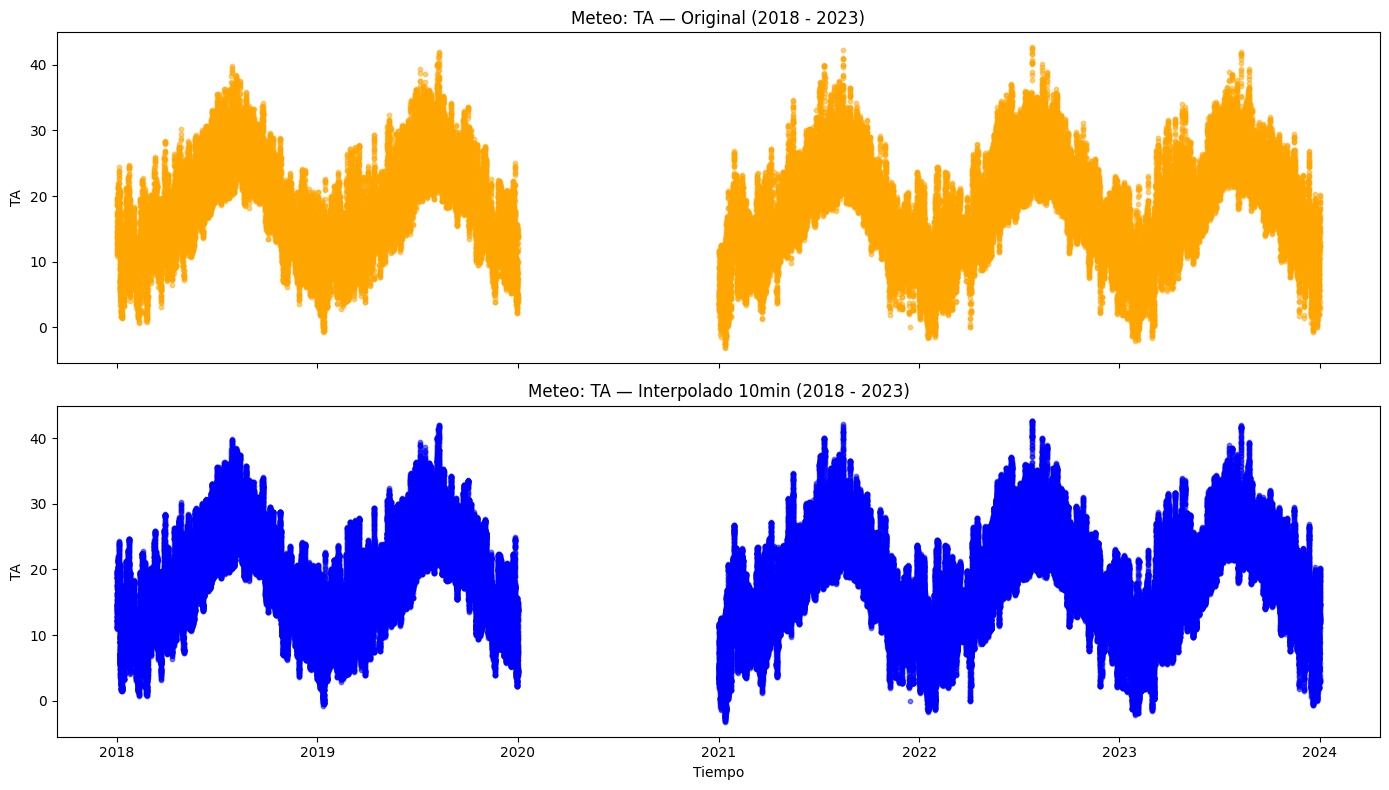

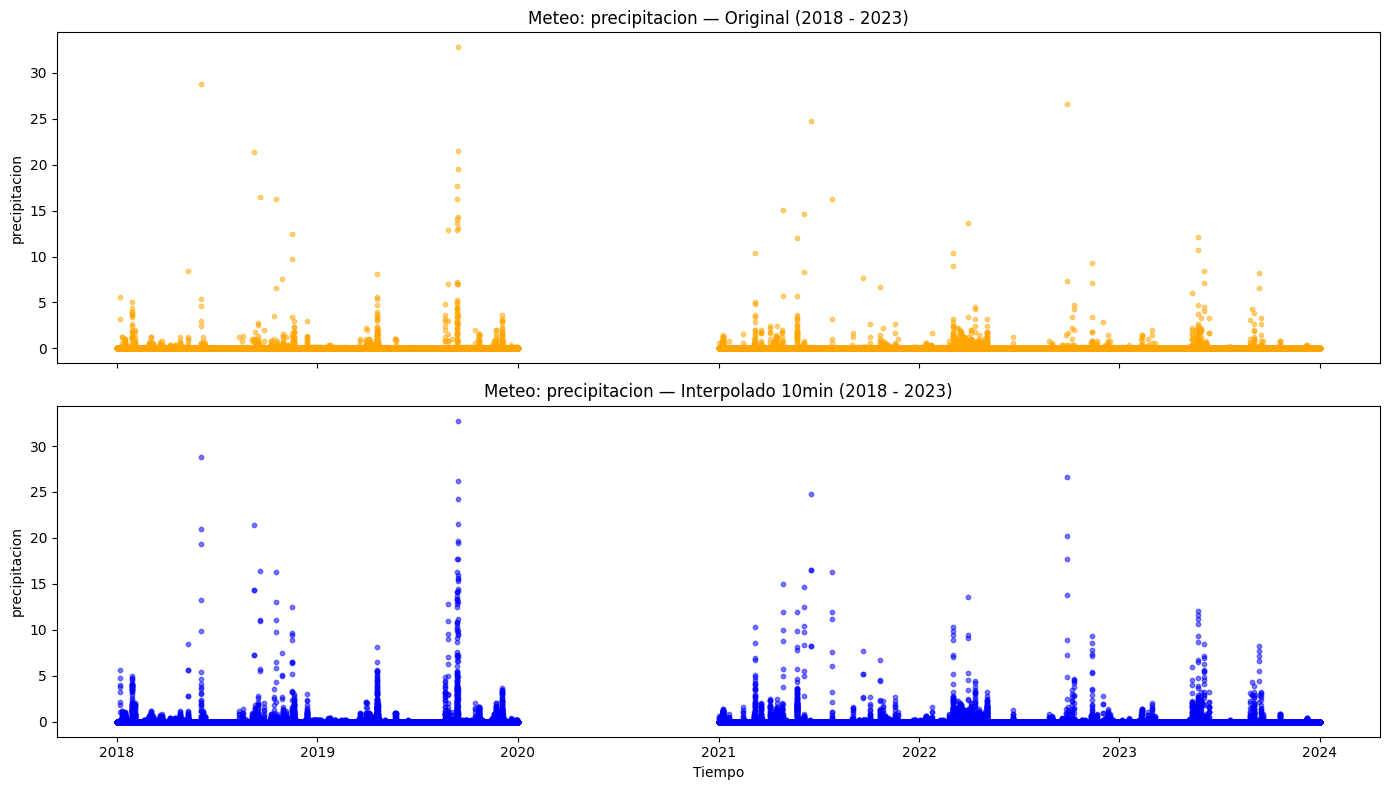

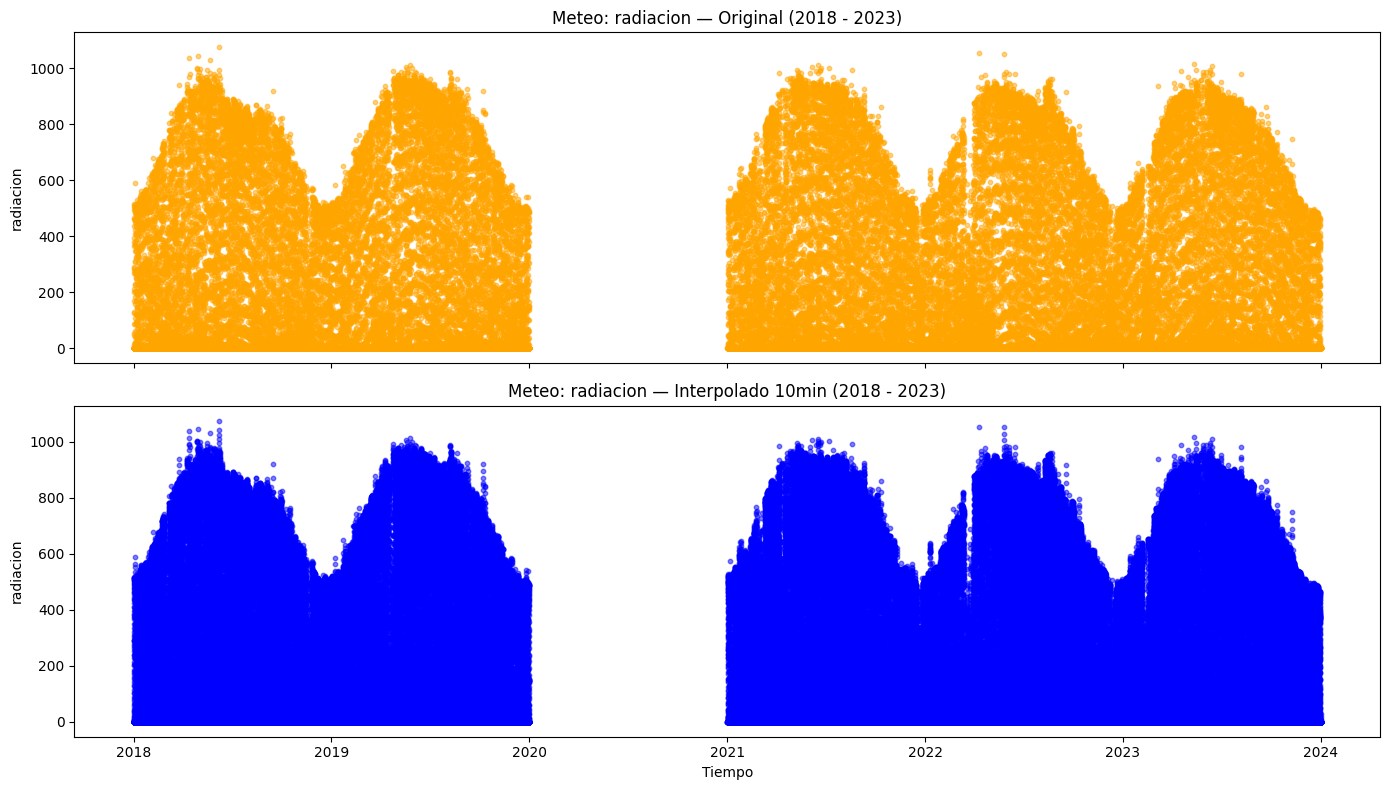

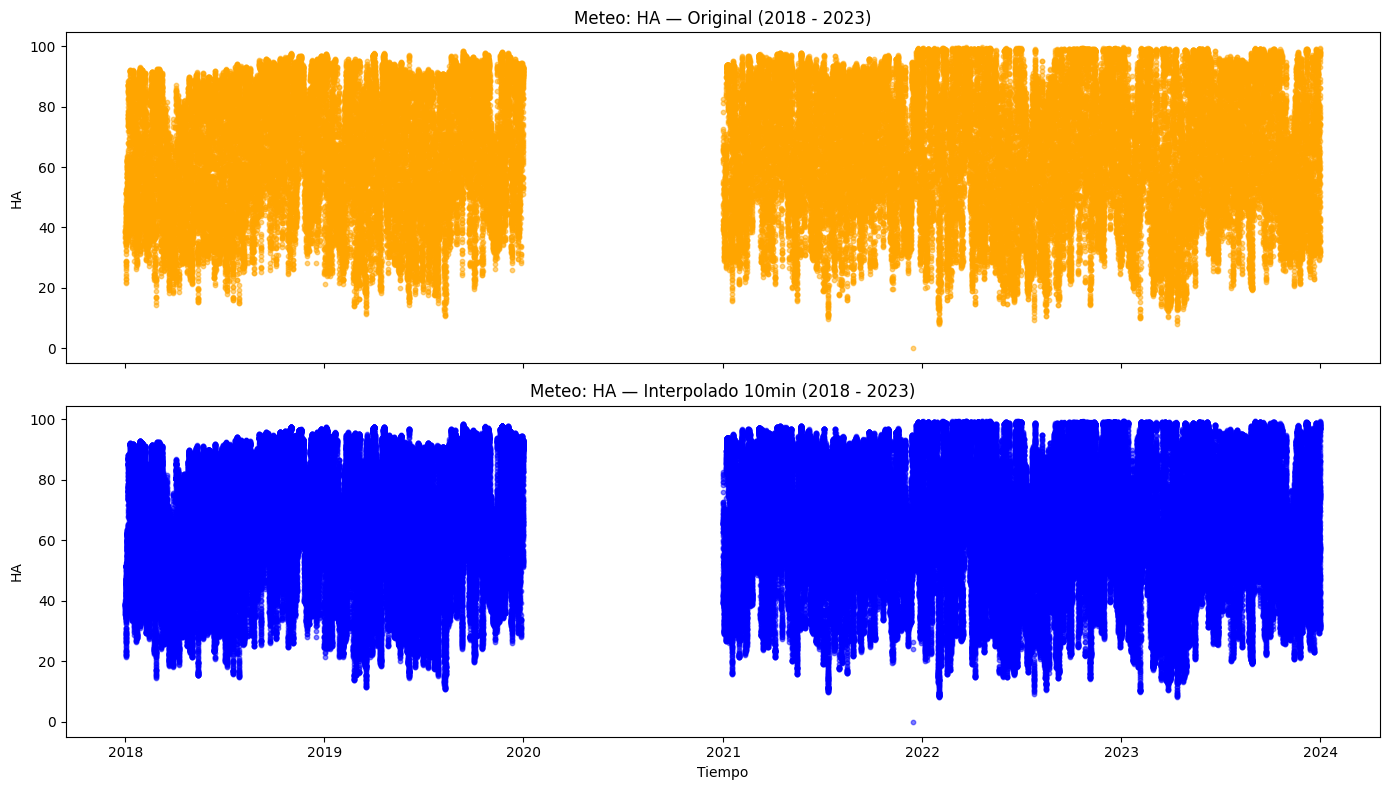

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_meteo = pd.read_csv("meteo_ivia.csv")
df_meteo["instante"] = pd.to_datetime(df_meteo["instante"])

df_meteo = df_meteo.drop(columns=["eto"], errors="ignore")

# Filtramos por los años especificados (2018, 2019, 2021, 2022, 2023)
df_before = df_meteo[df_meteo["instante"].dt.year.isin([2018, 2019, 2021, 2022, 2023])].copy()

def interpolate_meteo(dfy, freq="10min"):
    dfy = dfy.copy().sort_values("instante").set_index("instante")
    
    # Agrupar por fechas (opcional si deseas hacer un promedio por día o mes)
    dfy = dfy.groupby(level=0).mean()

    start = dfy.index.min().floor(freq)
    end   = dfy.index.max().ceil(freq)
    grid_idx = pd.date_range(start, end, freq=freq)

    # Generamos el rango de fechas (reindexando)
    df_all = dfy.reindex(dfy.index.union(grid_idx)).sort_index()
    
    # Interpolación lineal sobre los valores faltantes
    df_all = df_all.interpolate(method="time")

    # Devolvemos el dataframe con los valores interpolados
    out = df_all.loc[grid_idx].reset_index().rename(columns={"index": "instante"})
    return out

# Interpolar por año, manteniendo la independencia de cada año
meteo_all_10min = pd.concat(
    [interpolate_meteo(df_before[df_before["instante"].dt.year == year]) for year in [2018, 2019, 2021, 2022, 2023]],
    ignore_index=True
)

# Guardamos el dataset interpolado
meteo_all_10min.to_csv("meteo_clean_interpolated.csv", index=False)
print("Dataset meteorológico guardado como 'meteo_clean_interpolated.csv'")

# Función para graficar los datos antes y después de la interpolación
def plot_meteo_before_after(var, df_orig, df_interp):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Datos originales (frecuencia original)
    axes[0].scatter(df_orig["instante"], df_orig[var], s=10, color='orange', alpha=0.5)
    axes[0].set_title(f"Meteo: {var} — Original ({df_orig['instante'].dt.year.min()} - {df_orig['instante'].dt.year.max()})")
    axes[0].set_ylabel(var)

    # Datos interpolados (10 min)
    axes[1].scatter(df_interp["instante"], df_interp[var], s=10, color='blue', alpha=0.5)
    axes[1].set_title(f"Meteo: {var} — Interpolado 10min ({df_interp['instante'].dt.year.min()} - {df_interp['instante'].dt.year.max()})")
    axes[1].set_ylabel(var)
    axes[1].set_xlabel("Tiempo")

    plt.tight_layout()
    plt.show()

# Graficamos para las variables que necesitas
plot_meteo_before_after("TA", df_before, meteo_all_10min)
plot_meteo_before_after("precipitacion", df_before, meteo_all_10min)
plot_meteo_before_after("radiacion", df_before, meteo_all_10min)
plot_meteo_before_after("HA", df_before, meteo_all_10min)